In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

In [2]:
import json

# Reading the data from the JSON files
with open('tasks_mock_data.json', 'r') as f:
    tasks_data = json.load(f)

with open('engineer_mock_data.json', 'r') as f:
    engineers_data = json.load(f)

# Display first few rows to check the data
tasks_data[:3], engineers_data[:3]

([{'task_id': 1,
   'skill_required': 'Angular',
   'due_date': '1740908105',
   'priority': 'Low',
   'dependency_level': 'Critical',
   'module_knowledge': 5,
   'task_type': 'Story'},
  {'task_id': 2,
   'skill_required': 'Angular',
   'due_date': '1739866911',
   'priority': 'High',
   'dependency_level': 'Low',
   'module_knowledge': 13,
   'task_type': 'UI Improvement'},
  {'task_id': 3,
   'skill_required': 'Angular',
   'due_date': '1742917114',
   'priority': 'Medium',
   'dependency_level': 'Medium',
   'module_knowledge': 8,
   'task_type': 'UI Improvement'}],
 [{'engineer_id': 1,
   'skills': 'Spring Boot',
   'collab_ability': 'High',
   'availability_index': 21,
   'impact': 13,
   'module_exposure': 5,
   'efficiency': 1.23},
  {'engineer_id': 2,
   'skills': 'React',
   'collab_ability': 'Low',
   'availability_index': 8,
   'impact': 21,
   'module_exposure': 13,
   'efficiency': 1.79},
  {'engineer_id': 3,
   'skills': 'React',
   'collab_ability': 'Medium',
   'avail

In [3]:
# Group engineers by skills
grouped_engineers = {}
for engineer in engineers_data:
    skill = engineer['skills']
    if skill not in grouped_engineers:
        grouped_engineers[skill] = []
    grouped_engineers[skill].append(engineer)

# Group tasks by skill required
grouped_tasks = {}
for task in tasks_data:
    skill = task['skill_required']
    if skill not in grouped_tasks:
        grouped_tasks[skill] = []
    grouped_tasks[skill].append(task)

# Checking the groups
list(grouped_engineers.keys()), list(grouped_tasks.keys())


(['Spring Boot', 'React', 'Angular', 'Flutter'],
 ['Angular', 'React', 'Flutter', 'Spring Boot'])

In [7]:
# Simulated planning start date (from earlier calculation)
planning_start_timestamp = 1710151343  # March 11, 2024 @ 10:02:23 UTC

# Function to calculate time (in days until due date from planning date)
def calculate_time(due_date):
    # Convert due_date to integer if it's a string
    due_date = int(due_date) if isinstance(due_date, str) else due_date

    # Use the planning start timestamp instead of current time
    return (due_date - planning_start_timestamp) / (60 * 60 * 24)

# Function to calculate complexity
def calculate_complexity(impact, module_exposure, dependency_level=None):
    if dependency_level:
        dependency_dict = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
        return impact + module_exposure + dependency_dict.get(dependency_level, 0)
    else:
        return impact + module_exposure

# Calculate time and complexity for engineers
engineer_metrics = {}
for skill, engineers in grouped_engineers.items():
    engineer_metrics[skill] = []
    for engineer in engineers:
        time_value = engineer['availability_index']  # Assume each index unit = 1 day available
        complexity_value = calculate_complexity(engineer['impact'], engineer['module_exposure'])
        engineer_metrics[skill].append({
            'engineer_id': engineer['engineer_id'],
            'time': time_value,
            'complexity': complexity_value
        })

# Calculate time and complexity for tasks
task_metrics = {}
for skill, tasks in grouped_tasks.items():
    task_metrics[skill] = []
    for task in tasks:
        time_value = calculate_time(task['due_date'])  # Now based on planning start
        complexity_value = calculate_complexity(0, task['module_knowledge'], task['dependency_level'])
        task_metrics[skill].append({
            'task_id': task['task_id'],
            'time': time_value,
            'complexity': complexity_value
        })

# Display metrics for quick verification
engineer_metrics, task_metrics


({'Spring Boot': [{'engineer_id': 1, 'time': 21, 'complexity': 18},
   {'engineer_id': 7, 'time': 13, 'complexity': 55},
   {'engineer_id': 8, 'time': 13, 'complexity': 76},
   {'engineer_id': 13, 'time': 8, 'complexity': 39},
   {'engineer_id': 15, 'time': 8, 'complexity': 21},
   {'engineer_id': 23, 'time': 13, 'complexity': 26},
   {'engineer_id': 25, 'time': 8, 'complexity': 18},
   {'engineer_id': 28, 'time': 8, 'complexity': 26},
   {'engineer_id': 31, 'time': 8, 'complexity': 26},
   {'engineer_id': 33, 'time': 13, 'complexity': 21},
   {'engineer_id': 36, 'time': 8, 'complexity': 26},
   {'engineer_id': 37, 'time': 13, 'complexity': 55},
   {'engineer_id': 40, 'time': 8, 'complexity': 34},
   {'engineer_id': 43, 'time': 8, 'complexity': 26},
   {'engineer_id': 44, 'time': 21, 'complexity': 42},
   {'engineer_id': 49, 'time': 13, 'complexity': 26}],
  'React': [{'engineer_id': 2, 'time': 8, 'complexity': 34},
   {'engineer_id': 3, 'time': 13, 'complexity': 21},
   {'engineer_id'

In [8]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Create dataframes for easy manipulation
engineer_df = pd.DataFrame([(e['engineer_id'], e['time'], e['complexity']) for engineers in engineer_metrics.values() for e in engineers], columns=['engineer_id', 'time', 'complexity'])
task_df = pd.DataFrame([(t['task_id'], t['time'], t['complexity']) for tasks in task_metrics.values() for t in tasks], columns=['task_id', 'time', 'complexity'])

# Normalize the data
scaler = MinMaxScaler()
engineer_df[['time', 'complexity']] = scaler.fit_transform(engineer_df[['time', 'complexity']])
task_df[['time', 'complexity']] = scaler.fit_transform(task_df[['time', 'complexity']])

# Display the normalized data
engineer_df.head(), task_df.head()


(   engineer_id      time  complexity
 0            1  1.000000    0.079365
 1            7  0.384615    0.666667
 2            8  0.384615    1.000000
 3           13  0.000000    0.412698
 4           15  0.000000    0.126984,
    task_id      time  complexity
 0        1  0.738186    0.157895
 1        2  0.711630    0.421053
 2        3  0.789427    0.210526
 3        9  0.710675    0.421053
 4       14  0.539812    0.263158)

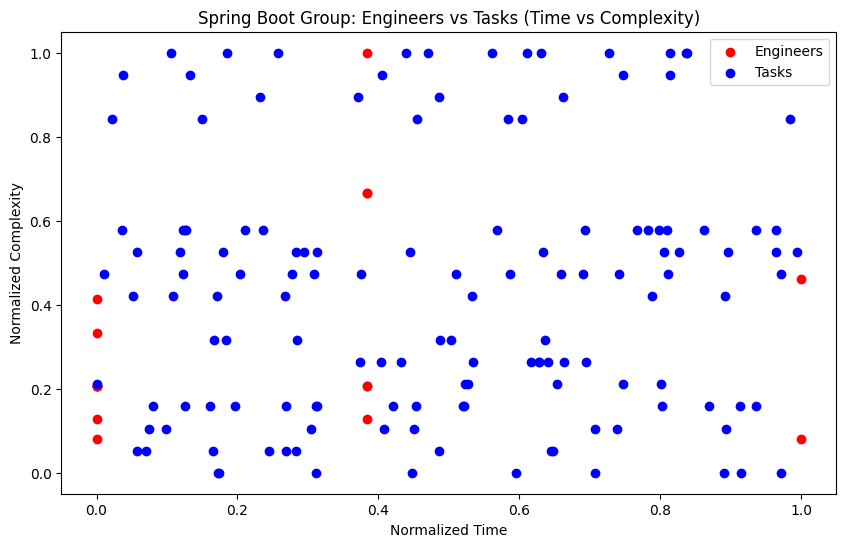

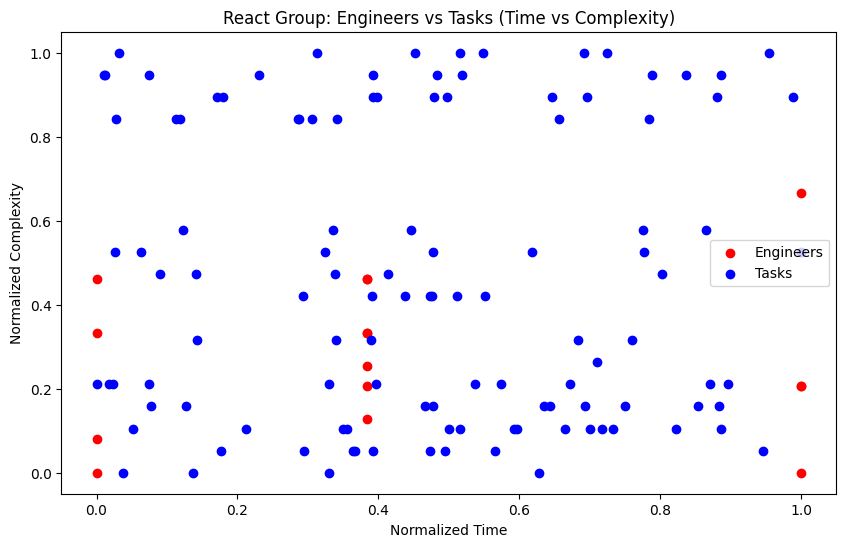

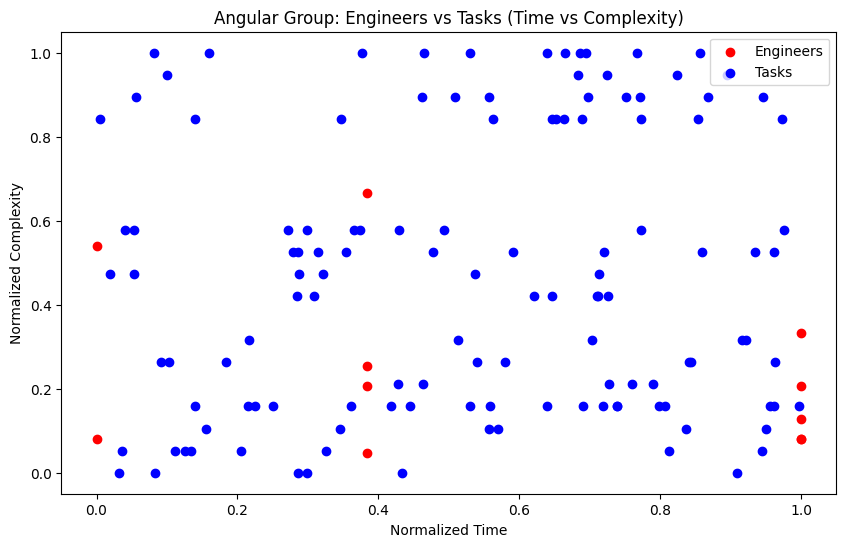

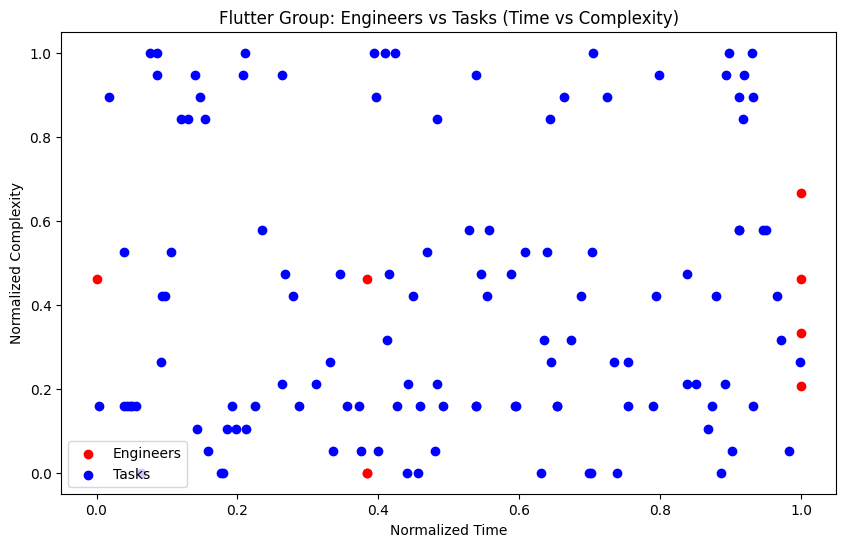

In [9]:
# Plot for each skill group
for skill in grouped_engineers.keys():
    # Create a figure for each skill group
    plt.figure(figsize=(10, 6))

    # Get the engineers and tasks for the skill group
    engineers = engineer_df[engineer_df['engineer_id'].isin([e['engineer_id'] for e in engineer_metrics.get(skill, [])])]
    tasks = task_df[task_df['task_id'].isin([t['task_id'] for t in task_metrics.get(skill, [])])]

    # Plot engineers (in red)
    plt.scatter(engineers['time'], engineers['complexity'], color='red', label='Engineers')

    # Plot tasks (in blue)
    plt.scatter(tasks['time'], tasks['complexity'], color='blue', label='Tasks')

    # Labels and title
    plt.xlabel('Normalized Time')
    plt.ylabel('Normalized Complexity')
    plt.title(f'{skill} Group: Engineers vs Tasks (Time vs Complexity)')
    plt.legend()

    # Show plot
    plt.show()
